## Healthcare ER Analytics Project

## Project Overview
This project analyzes hospital emergency room data using Python. The objective is to study patient flow, waiting times, admission patterns, and emergency room performance to generate meaninful operational insights.

## Project Goals
- Load and inspect the ER dataset
- Clean and prepare the data
- Explore trends and patient patterns
- Visualize emergency room performance

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [1]:
# ======================
# STEP 1: IMPORT LIBRARIES
# ======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")




Libraries imported successfully!


## Data Loading
In this section, the emergency room dataset is loaded into the notebook using Pandas.
After loading, the dataset shape and a preview of the records are checked to confirm that the file has been imported correctly.


In [2]:
# ======================
# STEP 2: LOAD THE DATASET
# ======================

file_path = "../data/Hospital ER_Data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 9216
Columns: 12


## Initial Preview
The first few rows are displayed to understand the structure of the dataset.

In [3]:
# Display the first 5 rows
df.head()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
0,145-39-5406,20-03-2024 08:47,H,Glasspool,M,69,White,NaN,False,10.0,39,0
1,316-34-3057,15-06-2024 11:29,X,Methuen,M,4,Native American/Alaska Native,NaN,True,NaN,27,0
2,897-46-3852,20-06-2024 09:13,P,Schubuser,F,56,African American,General Practice,True,9.0,55,0
3,358-31-9711,04-02-2024 22:34,U,Titcombe,F,24,Native American/Alaska Native,General Practice,True,8.0,31,0
4,289-26-0537,04-09-2024 17:48,Y,Gionettitti,M,5,African American,Orthopedics,False,NaN,10,0


## Column Inspection
Before cleaning the dataset, we inspect the column names exactly as they appear in the file

In [4]:
# Show all column names
df.columns.tolist()

['Patient Id',
 'Patient Admission Date',
 'Patient First Inital',
 'Patient Last Name',
 'Patient Gender',
 'Patient Age',
 'Patient Race',
 'Department Referral',
 'Patient Admission Flag',
 'Patient Satisfaction Score',
 'Patient Waittime',
 'Patients CM']

## Dataset Structure and Quality Check

This section reviews:
- dataset dimensions
- data types
- missing values
- overall summary information
These checks help identify data quality issues before cleaning and analysis.

In [5]:
# Basic info about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   str    
 1   Patient Admission Date      9216 non-null   str    
 2   Patient First Inital        9216 non-null   str    
 3   Patient Last Name           9216 non-null   str    
 4   Patient Gender              9216 non-null   str    
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   str    
 7   Department Referral         3816 non-null   str    
 8   Patient Admission Flag      9216 non-null   bool   
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
 11  Patients CM                 9216 non-null   int64  
dtypes: bool(1), float64(1), int64(3), str(7)
memory usage: 801.1 KB


In [6]:
# Check missing values in each column
df.isnull().sum()

Patient Id                       0
Patient Admission Date           0
Patient First Inital             0
Patient Last Name                0
Patient Gender                   0
Patient Age                      0
Patient Race                     0
Department Referral           5400
Patient Admission Flag           0
Patient Satisfaction Score    6699
Patient Waittime                 0
Patients CM                      0
dtype: int64

In [7]:
# Summary statistics
df.describe(include="all")

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
count,9216,9216,9216,9216,9216,9216.000000,9216,3816,9216,2517.000000,9216.000000,9216.000000
unique,9216,9176,26,8400,3,NaN,7,7,2,NaN,NaN,NaN
top,145-39-5406,11-10-2024 05:25,C,Haslum,M,NaN,White,General Practice,True,NaN,NaN,NaN
freq,1,2,383,4,4705,NaN,2571,1840,4612,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,39.855143,NaN,NaN,NaN,4.992054,35.259874,0.052083
std,NaN,NaN,NaN,NaN,NaN,22.755125,NaN,NaN,NaN,3.138043,14.735323,0.222207
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.000000,10.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,2.000000,23.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,5.000000,35.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,8.000000,48.000000,0.000000


## Standardizing Column Names

To make the dataset easier to work with, we clean the column names by:
- converting them to lowercase
- replacing spaces with underscores
- removing special characters where needed

In [8]:
# ======================
# STEP 3: CLEAN COLUMN NAMES
# ======================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_", regex=False)
    .str.replace("-", "_", regex=False)
)
print("Cleaned column names: ")
print(df.columns.tolist())

Cleaned column names: 
['patient_id', 'patient_admission_date', 'patient_first_inital', 'patient_last_name', 'patient_gender', 'patient_age', 'patient_race', 'department_referral', 'patient_admission_flag', 'patient_satisfaction_score', 'patient_waittime', 'patients_cm']


## Duplicate Check
Duplicate records can affect the accuracy of analysis, so the dataset is checked for repeated rows.

In [9]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


## Data Quality Summary
This summary table shows the most important information about each column:
- data type
- number of missing values
- number of unique values

In [10]:
# Create a summary table
data_quality = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.values,
    "missing_values": df.isnull().sum().values,
    "unique_values": df.nunique().values
})

data_quality

,column,data_type,missing_values,unique_values
0,patient_id,str,0,9216
1,patient_admission_date,str,0,9176
2,patient_first_inital,str,0,26
3,patient_last_name,str,0,8400
4,patient_gender,str,0,3
5,patient_age,int64,0,79
6,patient_race,str,0,7
7,department_referral,str,5400,7
8,patient_admission_flag,bool,0,2
9,patient_satisfaction_score,float64,6699,11


In [11]:
# Create a raw backup before cleaning further
df_raw = df.copy()
print("Raw backup copy created successfully.")

Raw backup copy created successfully.


## Converting Admission Date to Datetime

The `patient_admission_date` column is currently stored as a text field.
To enable time-based analysis such as hourly trends, daily patterns and monthly patient activity, the column is converted into a proper datetime format.

This transformation allows extraction of useful time-related features for further analysis.

In [12]:
# ======================
# STEP 4: CONVERT DATE COLUMN
# ======================

df["patient_admission_date"] = pd.to_datetime(
    df["patient_admission_date"],
    dayfirst=True,
    errors="coerce"
)

print("Date conversion completed.")
df["patient_admission_date"].head()

Date conversion completed.


0   2024-03-20 08:47:00
1   2024-06-15 11:29:00
2   2024-06-20 09:13:00
3   2024-02-04 22:34:00
4   2024-09-04 17:48:00
Name: patient_admission_date, dtype: datetime64[us]

In [13]:
# Check if any dates failed to convert
invalid_dates = df["patient_admission_date"].isnull().sum()

print(f"Invalid or missing dates after conversion: {invalid_dates}")

Invalid or missing dates after conversion: 0


## Numeric Data Validation

Some numeric fields maybe imported as text from CSV files.
To ensure accurate calculation and visualizations, the following columns are converted to numeric form:
- patient_age
- patient_satisfaction_score
- patient_waittime

In [14]:
# ======================
# STEP 5: ENSURE NUMERIC DATA TYPES
# ======================

numeric_columns = [
    "patient_age",
    "patient_satisfaction_score",
    "patient_waittime"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    
    print(df[numeric_columns].dtypes)

patient_age                     int64
patient_satisfaction_score    float64
patient_waittime                int64
dtype: object
patient_age                     int64
patient_satisfaction_score    float64
patient_waittime                int64
dtype: object
patient_age                     int64
patient_satisfaction_score    float64
patient_waittime                int64
dtype: object


## Feature Engineering

To support deeper analysis of patient flow and emergency room activity, additional time-based variables are derived from the admission timestamp.

New features include:
- admission_year
- admission_month
- admission_day
- admission_hour
- admission_day_name
- weekend indicator
These features help analyze temporal patterns in ER admissions.

In [15]:
# ======================
# STEP 6: CREATE TIME FEATURES
# ======================

df["admission_year"] = df["patient_admission_date"].dt.year
df["admission_month"] = df["patient_admission_date"].dt.month
df["admission_day"] = df["patient_admission_date"].dt.day
df["admission_hour"] = df["patient_admission_date"].dt.hour
df["admission_day_name"] = df["patient_admission_date"].dt.day_name()

df["is_weekend"] = df["admission_day_name"].isin(["Saturday", "Sunday"])

df[[
    "patient_admission_date",
    "admission_month",
    "admission_hour",
    "admission_day_name",
    "is_weekend"
]].head()

,patient_admission_date,admission_month,admission_hour,admission_day_name,is_weekend
0,2024-03-20 08:47:00,3,8,Wednesday,False
1,2024-06-15 11:29:00,6,11,Saturday,True
2,2024-06-20 09:13:00,6,9,Thursday,False
3,2024-02-04 22:34:00,2,22,Sunday,True
4,2024-09-04 17:48:00,9,17,Wednesday,False


## Patient Age Group Segmentation
To better understand patient demographics, age groups are created based on patient age.

Age categories used in the analysis:
- Child
- Teen
- Young Adult
- Adult
- Middle Age
- Senior
This segmentation enables demographic-level insights during exploratory analysis.

In [16]:
# ======================
# STEP 7: CREATE AGE GROUPS
# ======================

df["age_group"] =pd.cut(
    df["patient_age"],
    bins=[0,12,19,35,50,65,120],
    labels=[
        "Child",
        "Teen",
        "Young Adult",
        "Adult",
        "Middle Age",
        "Senior"
    ],
    include_lowest=True
)
df[["patient_age", "age_group"]].head()

,patient_age,age_group
0,69,Senior
1,4,Child
2,56,Middle Age
3,24,Young Adult
4,5,Child


## Exploratory Data Analysis

Exploratory Data Analysis(EDA) is performed to identify patterns, trends, and relationships within the dataset.

The analysis focuses on:
- patient demographics
- admission patterns
- emergency room wait times
- department referrals
- patient satisfaction levels


## Patient Age Distribution
This visualization helps understand the age distribution of patients visiting the emergency room.

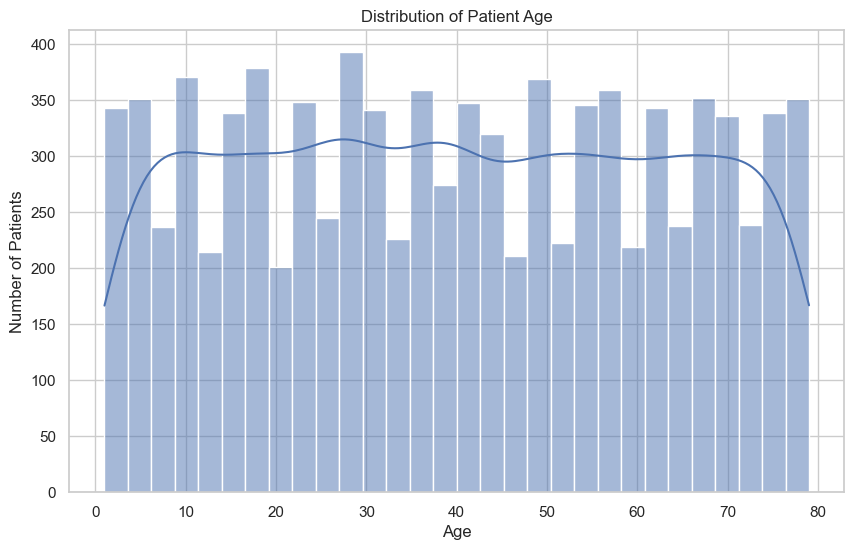

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(df["patient_age"], bins=30, kde=True)

plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

### Patient Gender Distribution
This chart shows the gender distribution of patients visiting the emergency department.

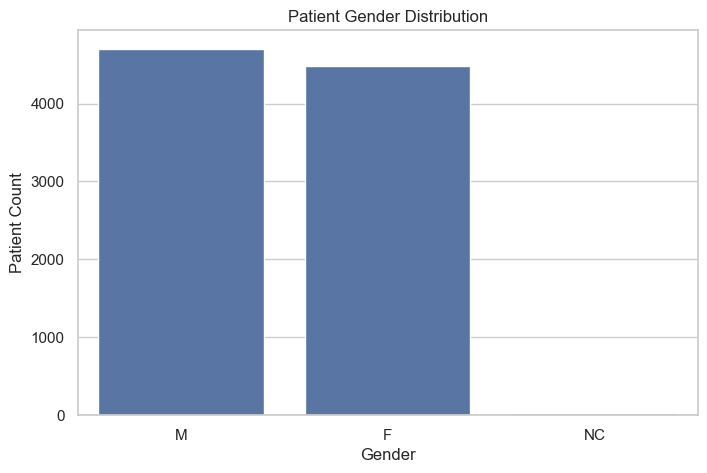

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="patient_gender")

plt.title("Patient Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Patient Count")

plt.show()

### Emergency Room Wait Time Distribution
This chart shows how long patients typically wait before recieving treatment in the emergency room.

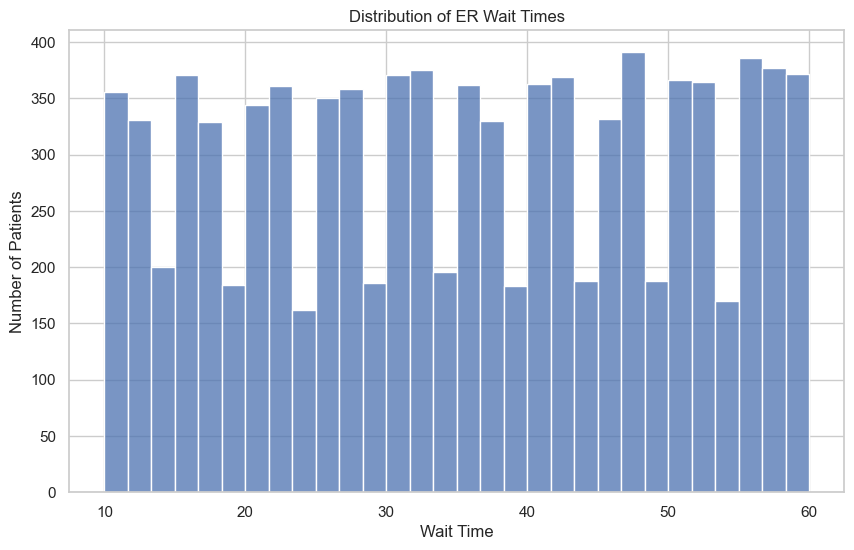

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(df["patient_waittime"], bins=30)

plt.title("Distribution of ER Wait Times")
plt.xlabel("Wait Time")
plt.ylabel("Number of Patients")

plt.show()

### Avergage Wait Time by Department Referral
This analysis evaluates which departments experience the longest patient wait times.

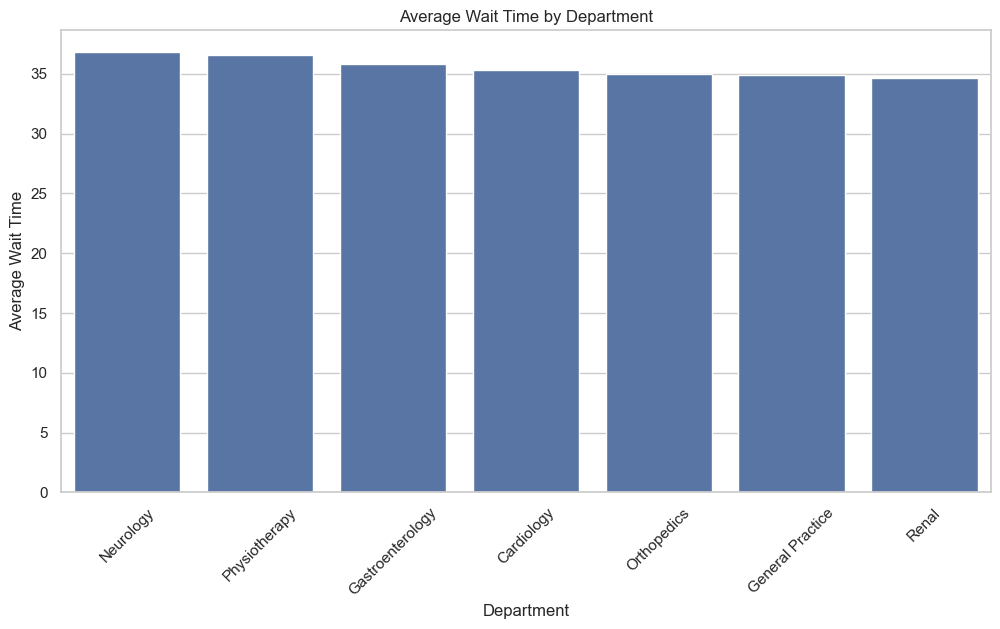

In [20]:
dept_wait = (
    df.groupby("department_referral")["patient_waittime"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(x=dept_wait.index, y=dept_wait.values)

plt.xticks(rotation=45)

plt.title("Average Wait Time by Department")
plt.xlabel("Department")
plt.ylabel("Average Wait Time")

plt.show()

### Relationship Between Wait Time and Patient Satisfaction

This visualization explores whether longer wait times influence patient satisfaction scores.

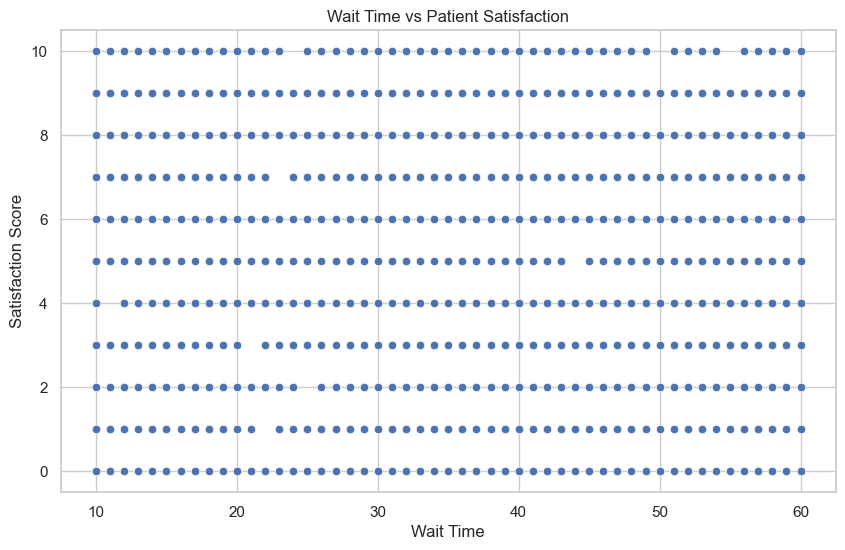

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="patient_waittime",
    y="patient_satisfaction_score"
)

plt.title("Wait Time vs Patient Satisfaction")
plt.xlabel("Wait Time")
plt.ylabel("Satisfaction Score")

plt.show()


## Peak Emergency Room Admission Hours

Understanding peak admission hours helps hospitals allocate staff more effectively and reduce patient wait times.
This analysis examines the number of ER admissions during different hours of the day.

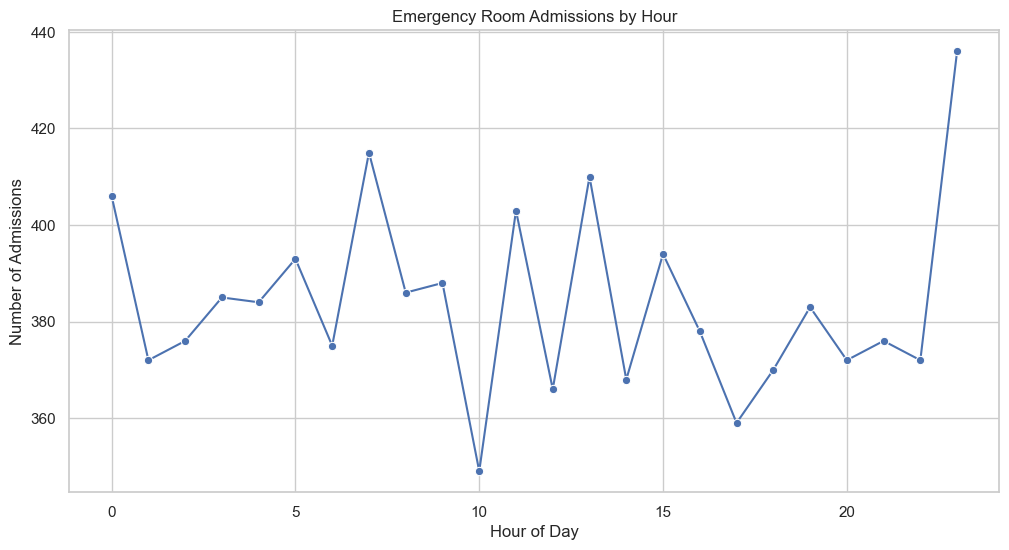

In [22]:
# ======================
# ER ADMISSIONS BY HOUR
# ======================

hourly_admissions = df["admission_hour"].value_counts().sort_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=hourly_admissions.index,
    y=hourly_admissions.values,
    marker="o"
)

plt.title("Emergency Room Admissions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Admissions")

plt.show()

## Emergency Room Visits by Day of Week
This visualization shows how ER visits vary across different days of the week. Identifying high-demand days can help hospitals optimize staffing schedules.

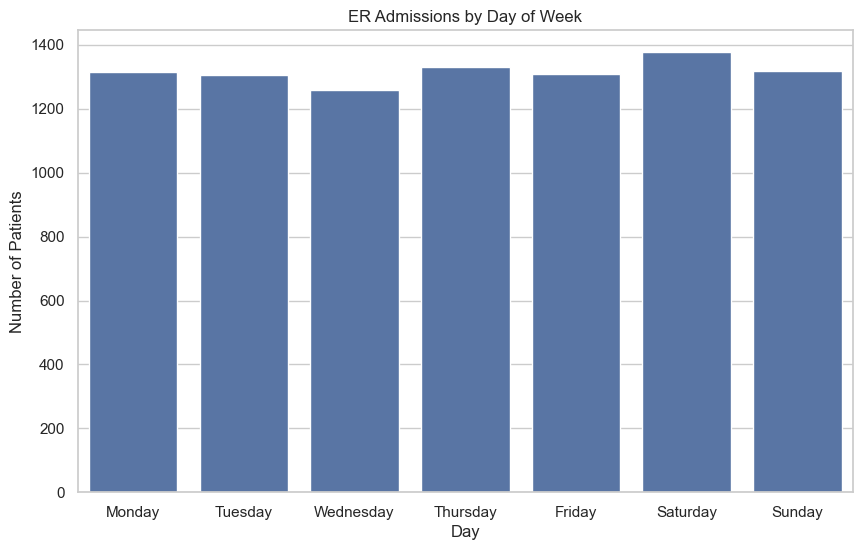

In [23]:
# ======================
# ADMISSIONS BY DAY
# ======================

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_counts = df["admission_day_name"].value_counts().reindex(day_order)

plt.figure(figsize=(10,6))

sns.barplot(
    x=day_counts.index,
    y=day_counts.values
)

plt.title("ER Admissions by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Patients")

plt.show()

## Department Referral Analysis
Patients arriving at the emergency room are often referred to different hospital departments receive the highest number of referrals.   hjkl;'

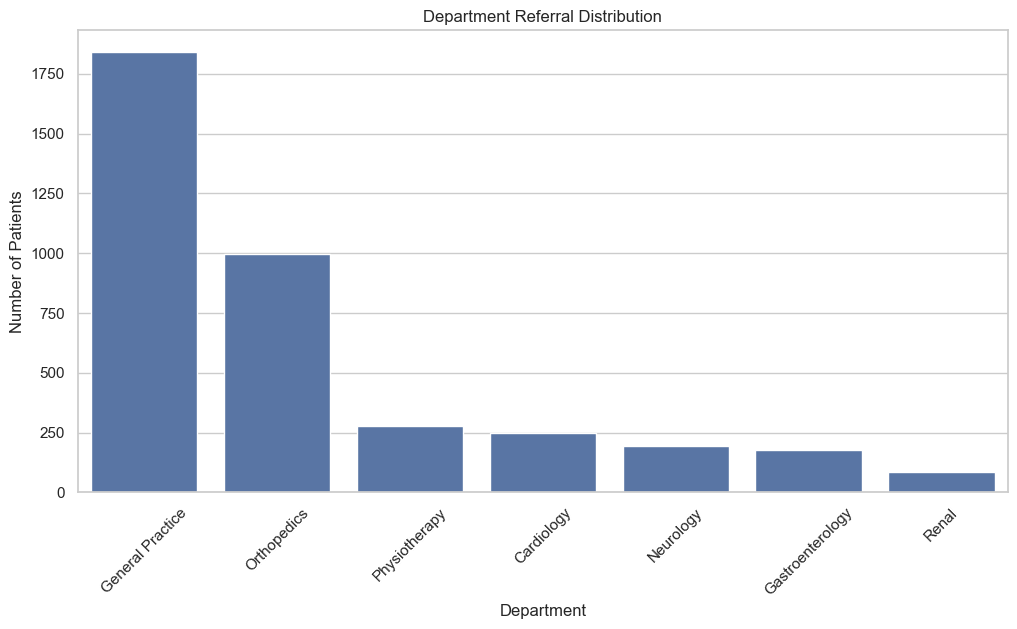

In [24]:
# ======================
# DEPARTMENT REFERRALS
# ======================

dept_counts = df["department_referral"].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=dept_counts.index,
    y=dept_counts.values
)

plt.xticks(rotation=45)

plt.title("Department Referral Distribution")
plt.xlabel("Department")
plt.ylabel("Number of Patients")

plt.show()

## Average Patient Satisfaction by Department

This analysis evaluates how patient satisfaction varies across departments. It helps identift areas where patient experience may need improvement.

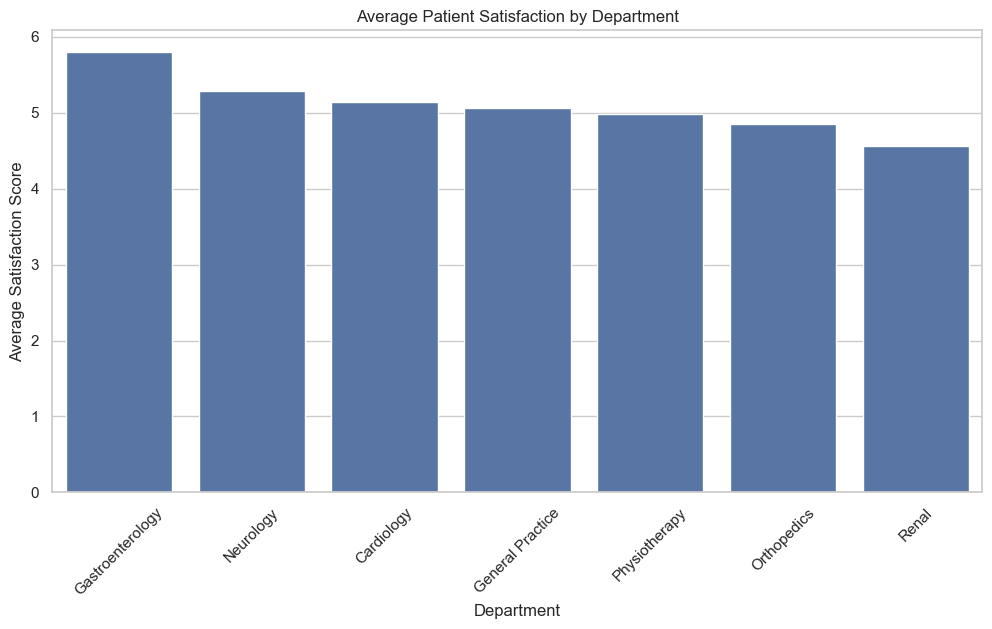

In [25]:
# ======================
# SATISFACTION BY DEPARTMENT
# ======================

dept_satisfaction = (
    df.groupby("department_referral")["patient_satisfaction_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=dept_satisfaction.index,
    y=dept_satisfaction.values
)
plt.xticks(rotation=45)

plt.title("Average Patient Satisfaction by Department")
plt.xlabel("Department")
plt.ylabel("Average Satisfaction Score")
plt.show()

## Average Wait Time by Age Group

This analysis explores whether certain patient age groups experience longer wait times in the emergency department.

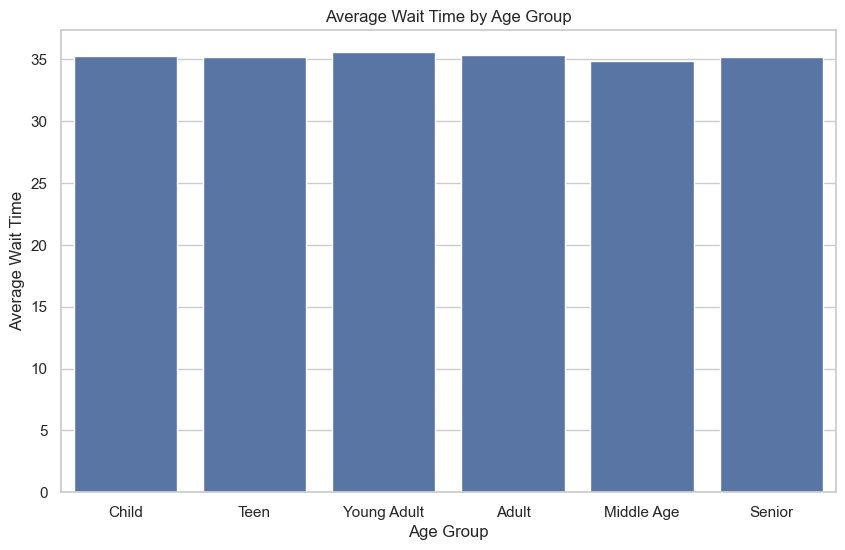

In [26]:
# ======================
# WAIT TIME BY AGE GROUP
# ======================

age_wait = (
    df.groupby("age_group")["patient_waittime"]
    .mean()
)
plt.figure(figsize=(10,6))

sns.barplot(
    x=age_wait.index,
    y=age_wait.values
)

plt.title("Average Wait Time by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Wait Time")
plt.show()


## Emergency Room Performance KPIs
To better understand overall emergency room performance, key operational indicators are calculated. These summary metrics provide a quick view of patient volume, average waiting time, satisfaction level, and admission activity.

In [27]:
# ======================
# STEP 8: KEY PERFORMANCE INDICATORS
# ======================

total_patients = len(df)
average_wait_time = df["patient_waittime"].mean()
average_satisfaction = df["patient_satisfaction_score"].mean()
average_age = df["patient_age"].mean()
admission_flag_distribution = df["patient_admission_flag"].value_counts(dropna=False)

print(f"Total Patients: {total_patients}")
print(f"Average Wait Time: {average_wait_time:.2f}")
print(f"Average Satisfaction Score: {average_satisfaction:.2f}")
print(f"Average Age: {average_age:.2f}")

print("\nAdmission Flag Distribution:")
print(admission_flag_distribution)


Total Patients: 9216
Average Wait Time: 35.26
Average Satisfaction Score: 4.99
Average Age: 39.86

Admission Flag Distribution:
patient_admission_flag
True     4612
False    4604
Name: count, dtype: int64


## Monthly Admission Trends
This analysis evaluates how emergency room admissions vary by month. Tracking monthly activity can help identify seasonal patterns in patient demand.

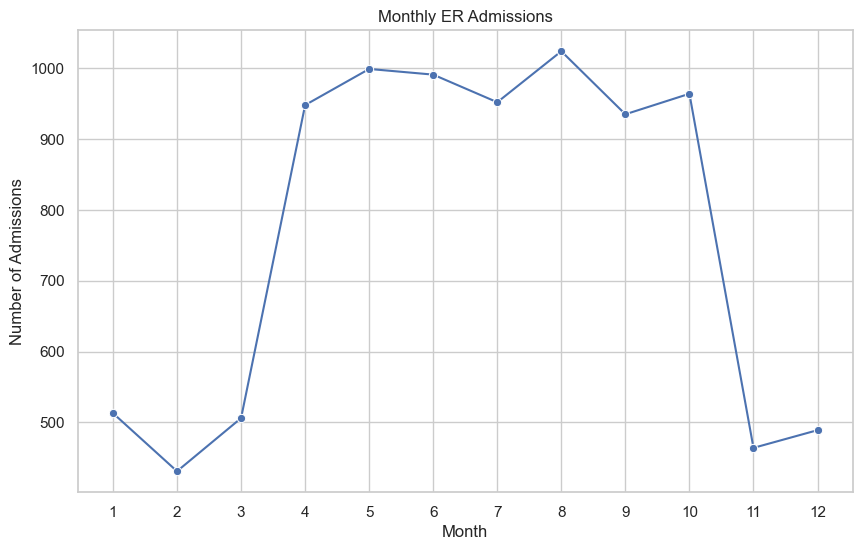

In [28]:
# ======================
# MONTHLY ADMISSION TREND
# ======================
monthly_admissions = df["admission_month"].value_counts().sort_index()

plt.figure(figsize=(10,6))

sns.lineplot(
    x=monthly_admissions.index,
    y=monthly_admissions.values,
    marker="o"
)

plt.title("Monthly ER Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(monthly_admissions.index)

plt.show()

## Weekend vs Weekday Emergency Room Activity

This analysis compares patient volume and waiting times between weekends and weekdays. It helps evaluate whether operational pressure changes based on the day type.

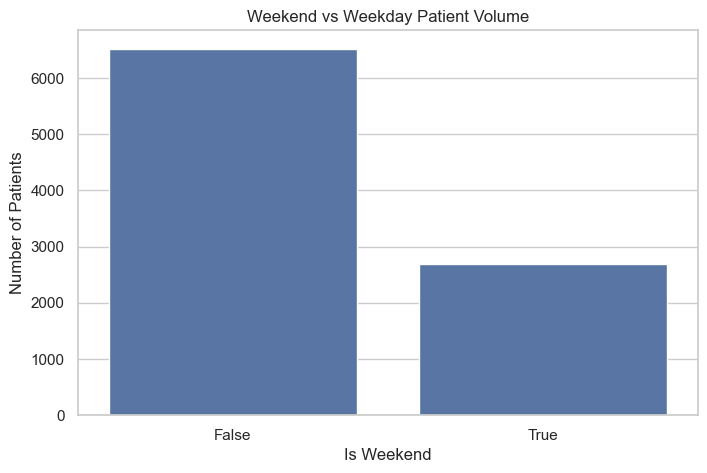

In [29]:
# ======================
# WEEKEND VS WEEKDAY PATIENT VOLUME
# ======================

weekend_counts = df["is_weekend"].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=weekend_counts.index.astype(str),
    y=weekend_counts.values
)

plt.title("Weekend vs Weekday Patient Volume")
plt.xlabel("Is Weekend")
plt.ylabel("Number of Patients")
plt.show()

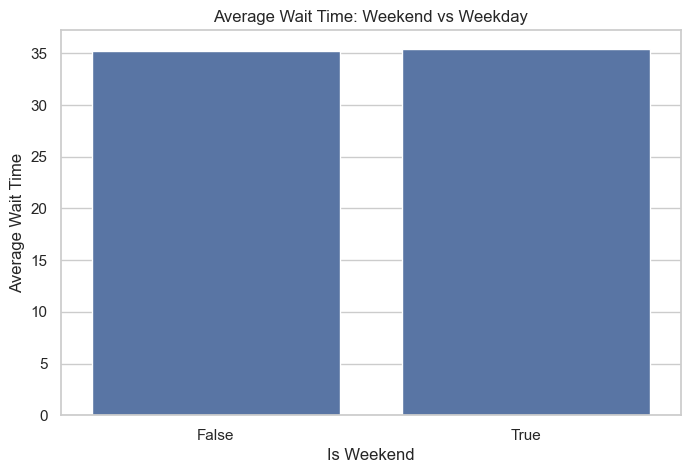

In [30]:
# Average wait time by weekend indicator

weekend_wait = df.groupby("is_weekend")["patient_waittime"].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=weekend_wait.index.astype(str),
    y=weekend_wait.values
)

plt.title("Average Wait Time: Weekend vs Weekday")
plt.xlabel("Is Weekend")
plt.ylabel("Average Wait Time")
plt.show()

## Patient Admission Flag Analysis
This section explores the distribution of the patient admission flag to better understand how many ER visits resulted in admissions versus non-admissions.

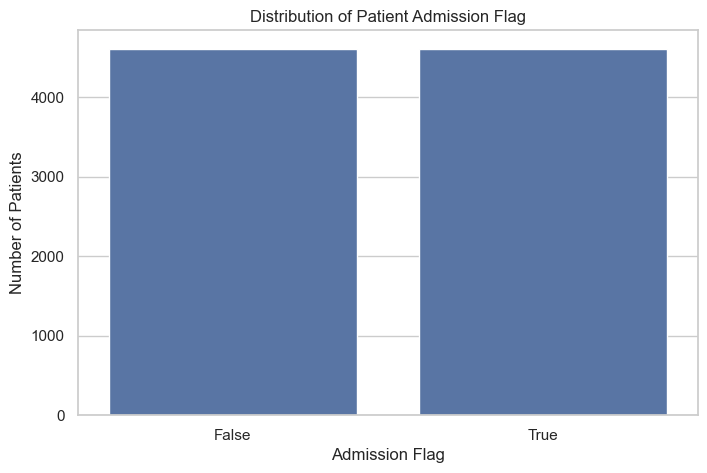

In [31]:
# ======================
# ADMISSION FLAG DISTRIBUTION
# ======================

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="patient_admission_flag")

plt.title("Distribution of Patient Admission Flag")
plt.xlabel("Admission Flag")
plt.ylabel("Number of Patients")

plt.show()

## Patient Satisfaction Score Distribution
This analysis shows the overall distribution of patient satisfaction scores and helps identify whether patient experience tends to be positive, neutral, or low,

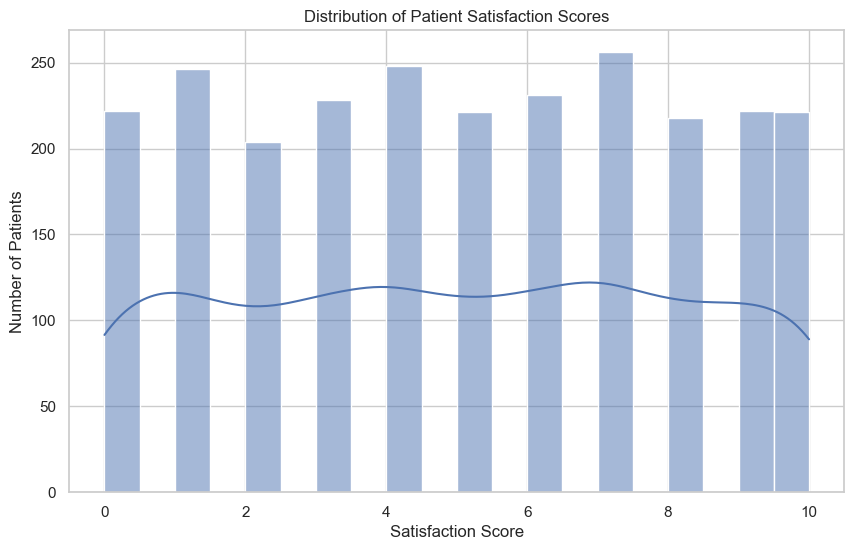

In [32]:
# ======================
# SATISFACTION SCORE DISTRIBUTION
# ======================

plt.figure(figsize=(10,6))

sns.histplot(df["patient_satisfaction_score"], bins=20, kde=True)

plt.title("Distribution of Patient Satisfaction Scores")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Patients")
plt.show()

## Correlation Analysis 
A correlation matrix is used to examine linear relationships between numerical variables in the dataset. This helps identify whether features such as age, wait time, and satisfaction score move together.

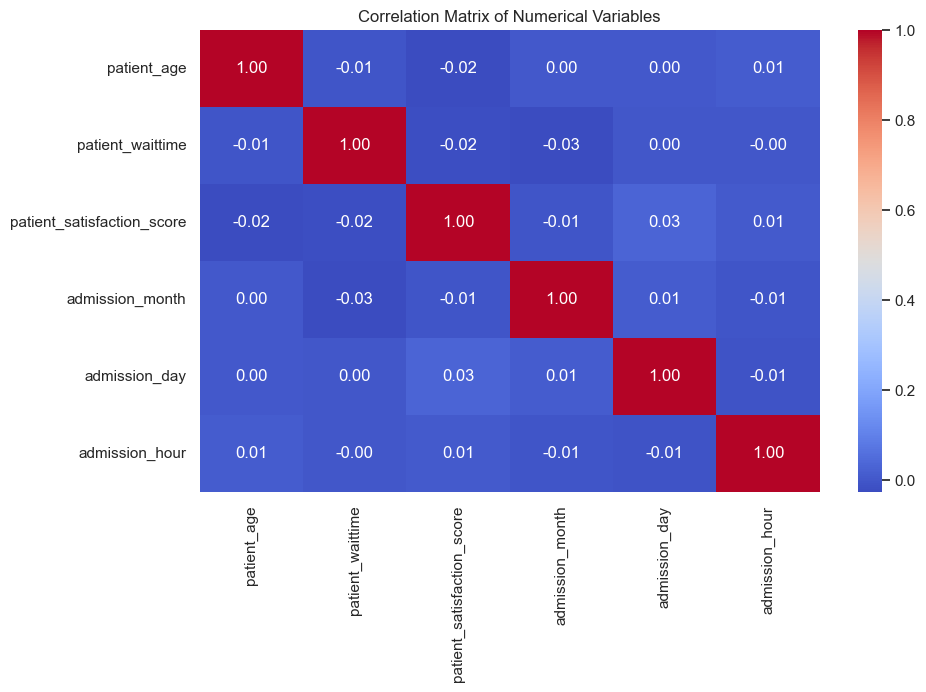

In [33]:
# ======================
# CORRELATION MATRIX
# ======================


corr_columns = [
    "patient_age",
    "patient_waittime",
    "patient_satisfaction_score",
    "admission_month",
    "admission_day",
    "admission_hour"
]

correlation_matrix = df[corr_columns].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

## Operational Summary by Department
This summary  table compares major performance indicators across departments, including patient count, avaergae wait time, and average satisfaction score.

In [34]:
# ======================
# DEPARTMENT SUMMARY TABLE
# ======================

department_summary = (
    df.groupby("department_referral")
    .agg(
        patient_count=("patient_id", "count"),
        avg_wait_time=("patient_waittime", "mean"),
        avg_satisfaction=("patient_satisfaction_score", "mean"),
        avg_age=("patient_age", "mean")
    )
    .sort_values(by="patient_count", ascending=False)
)

department_summary

,patient_count,avg_wait_time,avg_satisfaction,avg_age
department_referral,,,,
General Practice,1840,34.912500,5.061630,40.642935
Orthopedics,995,34.982915,4.858621,38.661307
Physiotherapy,276,36.565217,4.987952,39.597826
Cardiology,248,35.354839,5.140845,39.713710
Neurology,193,36.803109,5.283019,38.010363
Gastroenterology,178,35.831461,5.796296,42.303371
Renal,86,34.697674,4.565217,36.337209


## Departments with the Highest Average Wait Time
This section highlights the departments with the highest average waiting times, helping identify operational bottlenecks.

In [35]:
top_wait_departments = department_summary.sort_values(
    by="avg_wait_time",
    ascending=False
).head(5)

top_wait_departments

,patient_count,avg_wait_time,avg_satisfaction,avg_age
department_referral,,,,
Neurology,193,36.803109,5.283019,38.010363
Physiotherapy,276,36.565217,4.987952,39.597826
Gastroenterology,178,35.831461,5.796296,42.303371
Cardiology,248,35.354839,5.140845,39.713710
Orthopedics,995,34.982915,4.858621,38.661307


## Patient Segmentation Using K-Means Clustering

To explore whether natural patient groups exist in the dataset, K-Means clustering is applied using selected numerical variables:
- patient age
- patient wait time
- patient satisfaction score

This type of segmentation can help identify different patterns of patient experience and operational behavior.

In [36]:
# ======================
# STEP 9: PATIENT SEGMENTATION
# ======================

clustering_data = df[[
    "patient_age",
    "patient_waittime",
    "patient_satisfaction_score"
]].dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data)

In [37]:
# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

clustering_data = clustering_data.copy()
clustering_data["cluster"] = clusters

clustering_data.head()

,patient_age,patient_waittime,patient_satisfaction_score,cluster
0,69,39,10.0,0
2,56,55,9.0,0
3,24,31,8.0,2
8,79,42,1.0,1
19,55,40,2.0,1


In [38]:
# Cluster summary
cluster_summary = clustering_data.groupby("cluster").mean()
cluster_summary

,patient_age,patient_waittime,patient_satisfaction_score
cluster,,,
0,41.443005,47.783679,7.356218
1,41.947313,37.867229,1.743941
2,36.099246,20.293970,6.571608


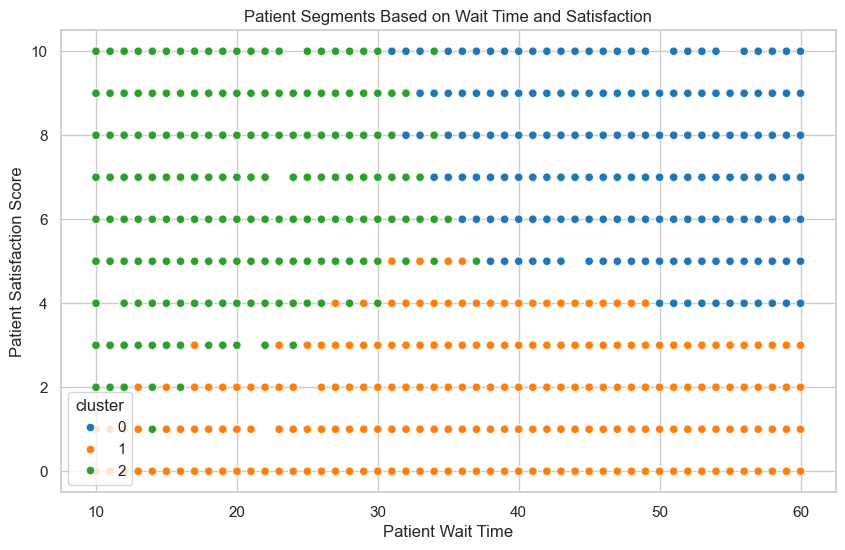

In [39]:
# Visualize clusters
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clustering_data,
    x="patient_waittime",
    y="patient_satisfaction_score",
    hue="cluster",
    palette="tab10"
)

plt.title("Patient Segments Based on Wait Time and Satisfaction")
plt.xlabel("Patient Wait Time")
plt.ylabel("Patient Satisfaction Score")

plt.show()

## Key Insights and Findings

Based on the exploratory and advanced analysis, several patterns can be identified in emergency room operations:

- patient arrivals vary by hour and day, indicating clear demand peaks
- wait times differ across departments, suggesting operational bottlenecks in certain areas
- satisfaction scores may be influenced by patient experience factors such as waiting time
- some age groups may experience different average wait times than others
- patient segmentation reveals that not all ER visits follow the same operational pattern

These findings can help healthcare administrators make more informed staffing and service decisions.

## Recommendations

Based on the analysis, the following recommendations can be made:

1. Increase staffing during peak admission hours to reduce waiting time pressure.
2. Review the departments with the highest average wait times for possible workflow improvements.
3. Monitor patient satisfaction more closely in departments with low average ratings.
4. Use time-based demand patterns to improve shift planning and resource allocation.
5. Explore patient segments further to design targeted service improvements for different patient groups.

## Conclusion

This project demonstrated an end-to-end healthcare analytics workflow using Python and Jupyter Notebook. The analysis covered data loading, cleaning, feature engineering, exploratory analysis, operational KPI tracking, and basic machine learning for patient segmentation.

The project provides valuable insight into emergency room patient flow, waiting times, referral patterns, and satisfaction levels. It also highlights how Python can be used to transform raw healthcare data into meaningful operational intelligence.

Overall, this project showcases both foundational and advanced data analytics skills in a real-world healthcare context.